# Where does the world waste its food?

A small analysis of the **UNEP Food Waste Index** (via Our World in Data):
how many kilograms of food each person wastes per year, by country, split into three places:

| Sector | What it means |
|---|---|
| **Household** | food thrown away at home |
| **Out-of-home consumption** | restaurants, canteens, hostel messes, hotels |
| **Retail** | shops and markets |

**Why I care:** I am building *Mess Saver*, an app that helps IIM Bangalore students give the hostel
mess advance notice of meals they will miss, so less food is cooked and wasted. This notebook puts
that problem in a global and Indian context.

**Questions**
1. Where in the food chain is most food wasted?
2. How does India compare with the world and other large countries?
3. Do richer countries waste more food at home?
4. What does this mean for a hostel mess like IIM Bangalore's?

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Chart style: colour-blind-safe palette, light grid, no box around the chart
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 11, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

## 2. Load the data

Files in `data/` were downloaded from Our World in Data:
- `food-waste-per-capita.csv`: kg of food waste per person per year, by sector (UNEP Food Waste Index)
- `gdp-per-capita-worldbank.csv`: GDP per person, in international dollars (World Bank)

In [2]:
waste = pd.read_csv("data/food-waste-per-capita.csv")
waste.head()

,Entity,Code,Year,Retail,Out-of-home consumption,Household
0,Afghanistan,AFG,2019,15.75,27.85,82.32
1,Afghanistan,AFG,2022,9.68,32.49,127.15
2,Africa (UN),UN_AFR,2019,15.43,27.34,110.03
3,Africa (UN),UN_AFR,2022,10.05,31.11,99.49
4,Albania,ALB,2019,15.68,27.72,82.99


In [3]:
print("Rows, columns:", waste.shape)
print()
print("Rows per year:")
print(waste["Year"].value_counts().sort_index())

Rows, columns: (554, 6)

Rows per year:
Year
2008      1
2009      1
2010      1
2011      1
2012      1
2013      1
2014      1
2015      1
2016      1
2017      2
2018      2
2019    233
2020     29
2021     29
2022    250
Name: count, dtype: int64


## 3. Check the data

Things to look for before trusting any numbers:
- **Missing values**: blanks in a column.
- **Rows that are not countries**: the file also has groups like "World" or "Africa (UN)".
- **Impossible values**: e.g. 0 kg of waste.
- **Which year to use**: most countries have **2019** (UNEP's 2021 report) and **2022** (2024 report).

In [4]:
waste.isna().sum()

Entity                     0
Code                       5
Year                       0
Retail                     4
Out-of-home consumption    2
Household                  2
dtype: int64

In [5]:
# Real countries have a 3-letter ISO code (e.g. IND). Groups have none, or codes like UN_AFR / OWID_WRL.
is_country = waste["Code"].fillna("").str.fullmatch("[A-Z]{3}")
print(sorted(waste.loc[~is_country, "Entity"].unique()))

['Africa (UN)', 'Asia (UN)', 'Australia and New Zealand (UN SDG)', 'Central and Southern Asia (UN SDG)', 'Developing regions', 'Eastern and South-Eastern Asia (UN SDG)', 'Europe (UN)', 'Europe and Northern America (UN SDG)', 'Latin America and the Caribbean (UN SDG)', 'Latin America and the Caribbean (UN)', 'Least Developed Countries (LDCs)', 'Northern Africa and Western Asia (UN SDG)', 'Northern America (UN)', 'Oceania (UN SDG)', 'Oceania (UN)', 'Small Island Developing States (SIDS)', 'Sub-Saharan Africa (UN SDG)', 'World']


**Important caveat:** the 2019 and 2022 numbers come from two different UNEP reports that used
**different methods and more data** the second time. So a change between 2019 and 2022 is mostly
a change in *measurement*, not in behaviour. This notebook therefore uses **2022 only** and
does not claim any trend.

In [6]:
SECTORS = ["Household", "Out-of-home consumption", "Retail"]

w22 = waste[waste["Year"] == 2022].copy()
w22["Total"] = w22[SECTORS].sum(axis=1)

world = w22[w22["Entity"] == "World"].iloc[0]
countries = w22[is_country.loc[w22.index]].dropna(subset=SECTORS)

# A few tiny territories (Vatican, Niue, ...) show 0 kg: that means "no estimate", not "no waste"
no_estimate = countries["Total"] == 0
print("Dropped (0 kg = no estimate):", list(countries.loc[no_estimate, "Entity"]))
countries = countries[~no_estimate]

print(len(countries), "countries with complete 2022 data")
countries[["Entity"] + SECTORS + ["Total"]].describe().round(1)

Dropped (0 kg = no estimate): ['Falkland Islands', 'Montserrat', 'Niue', 'Tokelau', 'Vatican']
228 countries with complete 2022 data


,Household,Out-of-home consumption,Retail,Total
count,228.0,228.0,228.0,228.0
mean,87.5,31.1,16.1,134.6
std,26.2,11.9,10.6,34.5
min,17.8,2.0,1.0,39.0
25%,75.7,24.4,9.7,117.9
50%,88.6,31.1,13.3,132.8
75%,92.7,39.6,19.0,153.3
max,206.0,79.7,78.8,260.4


## 4. Question 1: Where is most food wasted?

In [7]:
share = (world[SECTORS] / world[SECTORS].sum() * 100).round(0)
pd.DataFrame({"kg per person per year": world[SECTORS].round(1), "% of total": share})

,kg per person per year,% of total
Household,79.1,60.0
Out-of-home consumption,36.3,28.0
Retail,16.4,12.0


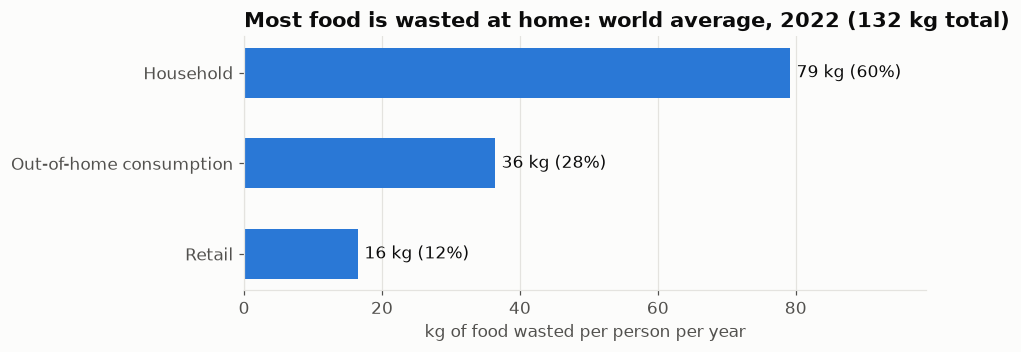

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
vals = world[SECTORS].astype(float)[::-1]          # biggest bar on top
bars = ax.barh(vals.index, vals.values, color=BLUE, height=0.55)
for bar, v in zip(bars, vals.values):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            f"{v:.0f} kg ({v / vals.sum():.0%})", va="center", color=INK)
ax.set_xlim(0, vals.max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_xlabel("kg of food wasted per person per year")
ax.set_title(f"Most food is wasted at home: world average, 2022 ({vals.sum():.0f} kg total)")
fig.savefig(CHARTS / "01_world_by_sector.png")
plt.show()

**Finding:** roughly 6 in 10 kg of wasted food are thrown away **at home**. Restaurants, canteens
and messes are the second-largest source, which is the part *Mess Saver* targets.

## 5. Question 2: How does India compare?

A handful of large or well-known countries, plus the world average.

In [9]:
PICK = ["India", "China", "United States", "United Kingdom", "Japan", "Germany",
        "Brazil", "Indonesia", "Nigeria", "Pakistan", "Bangladesh"]
compare = pd.concat([countries[countries["Entity"].isin(PICK)], w22[w22["Entity"] == "World"]])
compare = compare.set_index("Entity")[SECTORS + ["Total"]].sort_values("Total")
compare.round(1)

,Household,Out-of-home consumption,Retail,Total
Entity,,,,
Japan,59.7,12.0,8.9,80.6
United Kingdom,75.5,16.2,3.5,95.2
India,55.2,32.5,9.7,97.3
Germany,75.0,24.0,9.0,108.0
Bangladesh,82.4,32.5,9.7,124.6
World,79.1,36.3,16.4,131.9
China,76.2,45.6,19.8,141.6
Indonesia,53.5,40.1,49.9,143.5
Brazil,94.2,47.6,2.7,144.4


In [10]:
rank = int(countries["Household"].rank(ascending=False)[countries["Entity"] == "India"].iloc[0])
print(f"India's household waste: {compare.loc['India', 'Household']:.0f} kg per person, "
      f"rank {rank} of {len(countries)} (1 = most waste)")

India's household waste: 55 kg per person, rank 209 of 228 (1 = most waste)


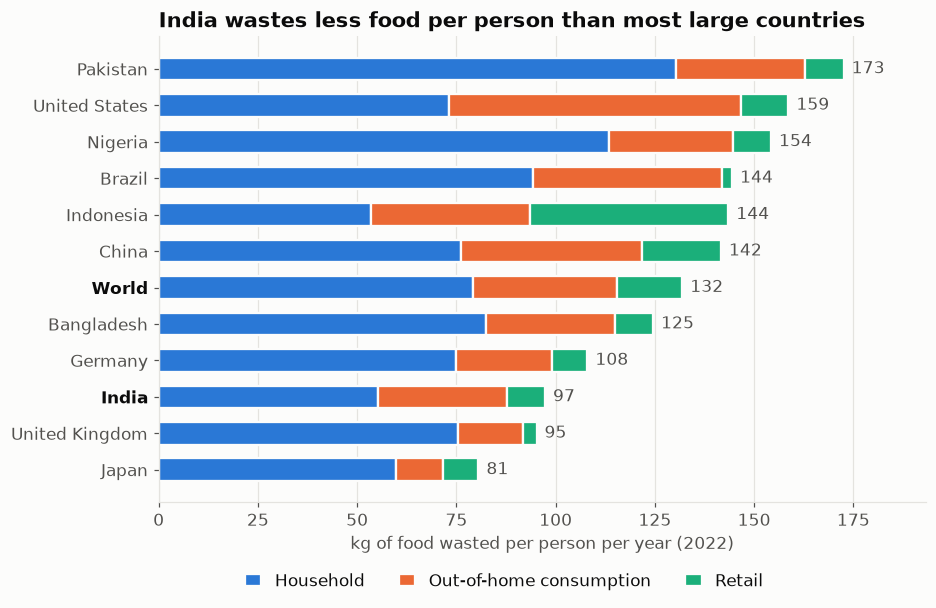

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
left = pd.Series(0.0, index=compare.index)
for sector, colour in zip(SECTORS, [BLUE, ORANGE, AQUA]):
    ax.barh(compare.index, compare[sector], left=left, color=colour, height=0.62,
            edgecolor="#fcfcfb", linewidth=1.5, label=sector)
    left += compare[sector]
for i, (name, total) in enumerate(compare["Total"].items()):
    ax.text(total + 2, i, f"{total:.0f}", va="center", color=INK_SOFT)
for label in ax.get_yticklabels():                 # make India and World stand out
    if label.get_text() in ("India", "World"):
        label.set_fontweight("bold"); label.set_color(INK)
ax.set_xlim(0, compare["Total"].max() * 1.12)
ax.grid(axis="y", visible=False)
ax.set_xlabel("kg of food wasted per person per year (2022)")
ax.set_title("India wastes less food per person than most large countries")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.45, -0.12), frameon=False,
          handlelength=1)
fig.savefig(CHARTS / "02_india_vs_countries.png")
plt.show()

**Finding:** India wastes about **97 kg per person per year**, below the world average of 132 kg,
and its **household** waste (55 kg) is among the lowest of all 228 countries.

**Caveat:** India, Pakistan and Bangladesh show *exactly* the same restaurant (32.5 kg) and retail
(9.7 kg) values. Identical numbers like that mean UNEP had no direct measurement and
**estimated them from a regional average**. Treat those two sectors for South Asia as rough.

In [12]:
# How common are such shared (estimated) values?
for s in SECTORS:
    shared = countries[s].duplicated(keep=False).mean()
    print(f"{s:<25} {shared:.0%} of countries share their exact value with another country")

Household                 20% of countries share their exact value with another country
Out-of-home consumption   45% of countries share their exact value with another country
Retail                    55% of countries share their exact value with another country


## 6. Question 3: Do richer countries waste more food at home?

A common belief is that wealth means more waste. Let's test it by joining each country's
**GDP per person** (World Bank, 2022) to its waste figures.

In [13]:
gdp = pd.read_csv("data/gdp-per-capita-worldbank.csv")
gdp22 = gdp.loc[gdp["Year"] == 2022, ["Code", "GDP per capita", "World region according to OWID"]]

merged = countries.merge(gdp22, on="Code", how="inner")
print(len(merged), "countries have both waste and GDP data")
print("Missing GDP (left out):", len(countries) - len(merged), "countries, e.g. small territories, Cuba, Venezuela")

198 countries have both waste and GDP data
Missing GDP (left out): 30 countries, e.g. small territories, Cuba, Venezuela


In [14]:
# Rank correlation: +1 = richer always wastes more, -1 = richer always wastes less, 0 = no link
ranks = merged[SECTORS + ["Total", "GDP per capita"]].rank()
ranks[SECTORS + ["Total"]].corrwith(ranks["GDP per capita"]).round(2).rename("correlation with GDP")

Household                 -0.23
Out-of-home consumption   -0.25
Retail                     0.22
Total                     -0.08
Name: correlation with GDP, dtype: float64

In [15]:
# Split countries into four equal groups by income and compare the typical (median) country
merged["Income group"] = pd.qcut(merged["GDP per capita"], 4,
                                 labels=["Poorest 25%", "Lower-middle 25%", "Upper-middle 25%", "Richest 25%"])
merged.groupby("Income group", observed=True)[SECTORS + ["Total"]].median().round(0)

,Household,Out-of-home consumption,Retail,Total
Income group,,,,
Poorest 25%,91.0,31.0,10.0,133.0
Lower-middle 25%,89.0,31.0,15.0,142.0
Upper-middle 25%,88.0,34.0,15.0,145.0
Richest 25%,76.0,24.0,13.0,115.0


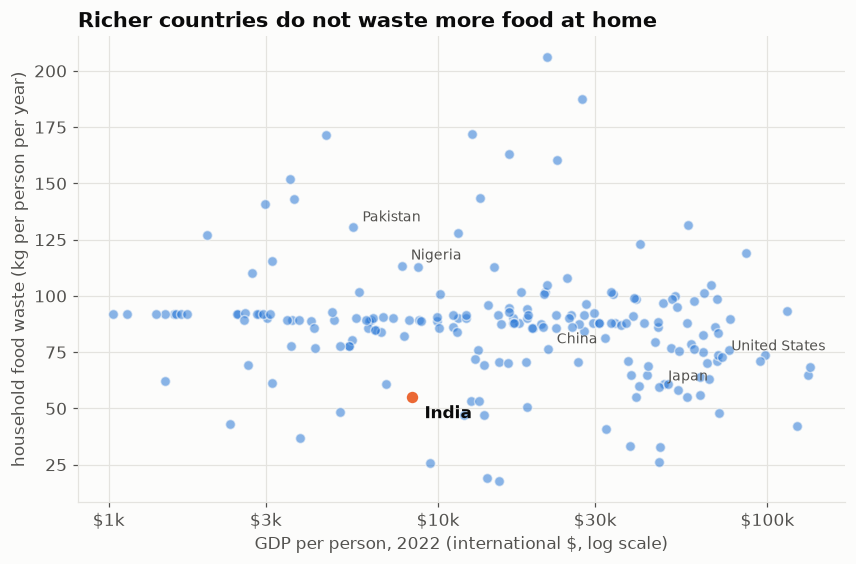

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
others = merged[merged["Entity"] != "India"]
india = merged[merged["Entity"] == "India"].iloc[0]
ax.scatter(others["GDP per capita"], others["Household"], s=42, color=BLUE, alpha=0.55,
           edgecolor="#fcfcfb", linewidth=1)
ax.scatter(india["GDP per capita"], india["Household"], s=90, color=ORANGE,
           edgecolor="#fcfcfb", linewidth=2, zorder=3)
ax.annotate("India", (india["GDP per capita"], india["Household"]), xytext=(8, -14),
            textcoords="offset points", fontweight="bold")
for name in ["United States", "Japan", "Nigeria", "Pakistan", "China"]:
    r = merged[merged["Entity"] == name].iloc[0]
    ax.annotate(name, (r["GDP per capita"], r["Household"]), xytext=(6, 4),
                textcoords="offset points", color=INK_SOFT, fontsize=9)
ax.set_xscale("log")
ax.set_xticks([1_000, 3_000, 10_000, 30_000, 100_000],
              ["$1k", "$3k", "$10k", "$30k", "$100k"])
ax.minorticks_off()
ax.set_xlabel("GDP per person, 2022 (international $, log scale)")
ax.set_ylabel("household food waste (kg per person per year)")
ax.set_title("Richer countries do not waste more food at home")
fig.savefig(CHARTS / "03_household_waste_vs_gdp.png")
plt.show()

**Finding:** No. The link between wealth and household waste is **weak and slightly negative**
(the richest quarter of countries is a little *lower*). Wasting food at home happens in rich and
poor countries alike, which matches UNEP's own conclusion. So better habits and better planning matter
more than income.

*(Note on the chart: the x-axis is on a "log scale", where each step is ×3 or ×10, because incomes
range from about $1,000 to over $100,000.)*

### 6a. How sure are we? Three checks

A single correlation number can mislead. Three standard checks:

1. **Bootstrap confidence interval**: re-sample the countries 5,000 times and recompute the
   correlation each time. The middle 95% of results is the range we can be confident about.
2. **Robustness check**: repeat it *without* countries whose household value is shared with another
   country (likely estimated, not measured).
3. **Regression controlling for region**: is any wealth effect really just "Europe is rich *and*
   wastes less"?

In [17]:
import numpy as np

def rank_corr(x, y):
    return np.corrcoef(pd.Series(x).rank(), pd.Series(y).rank())[0, 1]

def bootstrap_ci(df, n=5_000, seed=42):
    rng = np.random.default_rng(seed)
    x, y = df["GDP per capita"].to_numpy(), df["Household"].to_numpy()
    sims = [rank_corr(x[i], y[i]) for i in (rng.integers(0, len(df), len(df)) for _ in range(n))]
    return rank_corr(x, y), *np.percentile(sims, [2.5, 97.5])

measured = merged[~merged["Household"].duplicated(keep=False)]   # drop shared (estimated) values

checks = pd.DataFrame(
    [bootstrap_ci(merged), bootstrap_ci(measured)],
    index=[f"All countries (n={len(merged)})", f"Likely-measured only (n={len(measured)})"],
    columns=["correlation", "95% CI low", "95% CI high"],
).round(2)
checks

,correlation,95% CI low,95% CI high
All countries (n=198),-0.23,-0.36,-0.09
Likely-measured only (n=154),-0.13,-0.29,0.03


In [18]:
import statsmodels.formula.api as smf

reg_data = merged.rename(columns={"World region according to OWID": "region"}).copy()
reg_data["log10_gdp"] = np.log10(reg_data["GDP per capita"])

def wealth_effect(formula, data):
    fit = smf.ols(formula, data=data).fit(cov_type="HC3")   # HC3 = robust to unequal spread
    low, high = fit.conf_int().loc["log10_gdp"]
    return {"kg per 10x GDP": fit.params["log10_gdp"], "95% CI low": low,
            "95% CI high": high, "p-value": fit.pvalues["log10_gdp"], "R²": fit.rsquared}

reg_measured = reg_data[reg_data["Code"].isin(measured["Code"])]
pd.DataFrame({
    "GDP only":            wealth_effect("Household ~ log10_gdp", reg_data),
    "GDP + region":        wealth_effect("Household ~ log10_gdp + C(region)", reg_data),
    "GDP + region, measured only": wealth_effect("Household ~ log10_gdp + C(region)", reg_measured),
}).T.round(3)

,kg per 10x GDP,95% CI low,95% CI high,p-value,R²
GDP only,-8.637,-14.736,-2.537,0.006,0.027
GDP + region,1.245,-10.307,12.796,0.833,0.123
"GDP + region, measured only",1.465,-13.183,16.112,0.845,0.112


**How to read this:** "kg per 10x GDP" is how much household waste changes when a country is
ten times richer. If the 95% CI range includes 0, we can't rule out "no effect at all".

**Finding:**
- On its own, GDP explains only **about 3%** of the differences between countries (R² = 0.027).
- The slight negative link **disappears once continent is taken into account** (about +1 kg per 10x GDP,
  p = 0.83). It came from Europe being both rich *and* lower-waste, not from wealth itself.
- It also weakens when likely-estimated values are removed (the bootstrap range then includes 0).

**Conclusion:** there is **no reliable link between a country's wealth and how much food its households
waste**. Waste at home is a habit-and-planning problem everywhere, not a "rich country" problem.

## 7. Question 4: What could this mean for a hostel mess?

This is a back-of-the-envelope estimate for the IIM Bangalore mess. It is **not** from the UNEP data;
the inputs are the working estimates used in the *Mess Saver* project.

In [19]:
STUDENTS = 1_500
MEALS_WASTED_PER_DAY = (50, 100)    # meals cooked for students who did not turn up (low, high)
KG_PER_MEAL = 0.4
RUPEES_PER_MEAL = 70

rows = []
for meals in MEALS_WASTED_PER_DAY:
    per_year = meals * 365
    rows.append({
        "meals wasted per day": meals,
        "meals per year": per_year,
        "tonnes per year": per_year * KG_PER_MEAL / 1000,
        "kg per student per year": per_year * KG_PER_MEAL / STUDENTS,
        "₹ lakh per year": per_year * RUPEES_PER_MEAL / 100_000,
    })
mess = pd.DataFrame(rows).set_index("meals wasted per day")
mess.round(1)

,meals per year,tonnes per year,kg per student per year,₹ lakh per year
meals wasted per day,,,,
50,18250,7.3,4.9,12.8
100,36500,14.6,9.7,25.6


In [20]:
low, high = mess["kg per student per year"]
india_out = countries.loc[countries["Entity"] == "India", "Out-of-home consumption"].iloc[0]
print(f"Mess no-shows alone: about {low:.0f}-{high:.0f} kg per student per year.")
print(f"For comparison, UNEP's estimate of out-of-home waste for an average person in India: {india_out:.0f} kg per year.")

Mess no-shows alone: about 5-10 kg per student per year.
For comparison, UNEP's estimate of out-of-home waste for an average person in India: 32 kg per year.


**Finding:** cooking for students who don't turn up could waste roughly **7 to 15 tonnes of food a
year**, worth about **₹13 to 26 lakh**, in a single campus mess. Giving the mess notice
ahead of time is a cheap way to cut part of that.

### 7a. Scenario model: what if students give notice?

If a share of the students who skip a meal tell the mess in advance, the mess can cook that much
less. The table shows yearly savings for different **notice rates** (the share of skipped meals
notified ahead) and the three waste levels (low / middle / high estimate).

In [21]:
NOTICE_RATES = [0.25, 0.50, 0.75]
LEVELS = {"low (50/day)": 50, "middle (75/day)": 75, "high (100/day)": 100}

scenario = pd.DataFrame(
    {f"{rate:.0%} give notice": {name: meals * 365 * rate * RUPEES_PER_MEAL / 100_000
                                 for name, meals in LEVELS.items()}
     for rate in NOTICE_RATES}
)
print("Money saved per year (₹ lakh):")
scenario.round(1)

Money saved per year (₹ lakh):


,25% give notice,50% give notice,75% give notice
low (50/day),3.2,6.4,9.6
middle (75/day),4.8,9.6,14.4
high (100/day),6.4,12.8,19.2


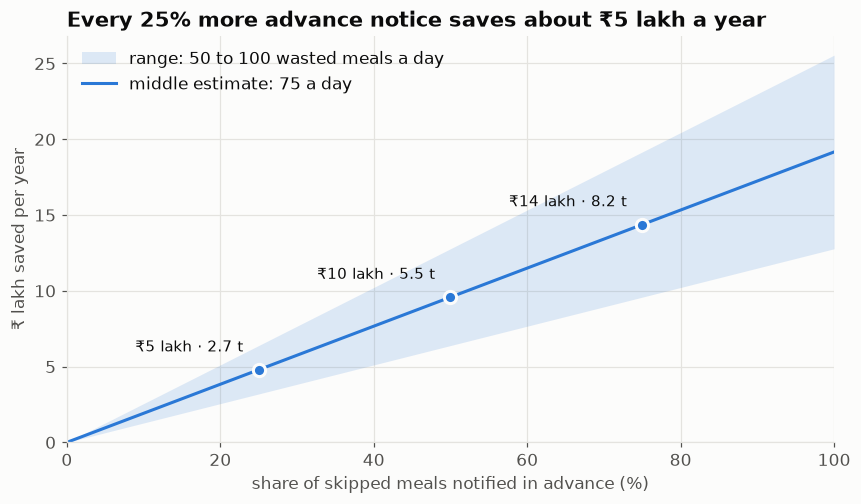

In [22]:
rates = np.linspace(0, 1, 101)
def lakh(meals): return meals * 365 * rates * RUPEES_PER_MEAL / 100_000
def tonnes(meals, rate): return meals * 365 * rate * KG_PER_MEAL / 1000

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.fill_between(rates * 100, lakh(50), lakh(100), color=BLUE, alpha=0.15, linewidth=0,
                label="range: 50 to 100 wasted meals a day")
ax.plot(rates * 100, lakh(75), color=BLUE, linewidth=2, label="middle estimate: 75 a day")
for rate in NOTICE_RATES:
    y = 75 * 365 * rate * RUPEES_PER_MEAL / 100_000
    ax.scatter(rate * 100, y, s=64, color=BLUE, edgecolor="#fcfcfb", linewidth=2, zorder=3)
    ax.annotate(f"₹{y:.0f} lakh · {tonnes(75, rate):.1f} t", (rate * 100, y), xytext=(-10, 12),
                textcoords="offset points", ha="right", fontsize=10)
ax.set_xlim(0, 100); ax.set_ylim(0, None)
ax.set_xlabel("share of skipped meals notified in advance (%)")
ax.set_ylabel("₹ lakh saved per year")
ax.set_title("Every 25% more advance notice saves about ₹5 lakh a year")
ax.legend(loc="upper left", frameon=False)
fig.savefig(CHARTS / "04_mess_savings_scenarios.png")
plt.show()

**Finding:** at the middle estimate, if **half** of skipped meals are notified in advance, the mess
could save about **₹10 lakh and 5.5 tonnes of food a year**. Each extra 25% of notice adds roughly
₹5 lakh. *(This assumes the mess really does cook less when told; that is the behaviour Mess Saver
is designed to support.)*

## 8. Summary

| # | Question | Answer |
|---|---|---|
| 1 | Where is food wasted? | **60% at home**, 28% in restaurants/canteens/messes, 12% in shops (world, 2022) |
| 2 | India vs others? | India wastes **97 kg/person/year** vs a world average of **132 kg**; its household waste is among the lowest |
| 3 | Do richer countries waste more at home? | **No reliable link.** GDP explains ~3% of the differences, and the effect vanishes after controlling for continent |
| 4 | What about a hostel mess? | No-shows may waste about **7–15 tonnes, about ₹13–26 lakh a year** at IIM Bangalore; if half give notice, about **₹10 lakh a year** could be saved (rough estimates) |

## 9. Limitations

- **Many values are estimates, not measurements.** Where a country has no study, UNEP fills the gap
  from similar countries (shown by identical values), so this applies to South Asia's restaurant and retail figures.
- **2019 vs 2022 are not comparable** (methods changed), so no trends are claimed.
- **Correlation is not causation.** GDP is one rough measure of wealth; diet, climate and culture also matter.
  The regression only controls for continent, not for these.
- **The mess estimate** rests on assumed inputs (meals wasted per day, kg and ₹ per meal); real
  weighing data from the mess would replace them.

**Sources:** UNEP Food Waste Index Report 2024, and World Bank GDP per capita (PPP), both via
[Our World in Data](https://ourworldindata.org/).